In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [2]:
# df = pd.read_csv('/kaggle/input/comment-sentiment/reviews.csv')
# df = df.dropna(subset=['text'])

df_train = pd.read_csv('/kaggle/input/reviews/reviews_train_cleaned.csv')
df_val = pd.read_csv('/kaggle/input/reviews/reviews_val_cleaned.csv')
df_test = pd.read_csv('/kaggle/input/reviews/reviews_test_cleaned.csv')


In [3]:
def convert_rating_to_label(rating):
    if rating <= 2: return '1'
    elif rating == 3: return '3'
    else: return '5'

df_train['sentiment'] = df_train['rating'].apply(convert_rating_to_label)
df_val['sentiment'] = df_val['rating'].apply(convert_rating_to_label)
df_test['sentiment'] = df_test['rating'].apply(convert_rating_to_label)

# def clean_text(text):
#     text = str(text).lower()
#     text = re.sub(r'[^\w\s]', '', text) 
#     return text

# df['clean_text'] = df['text'].apply(clean_text)

# print(f"Total samples: {len(df)}")
# print("Label Distribution:", df['sentiment'].value_counts().to_dict())

In [ ]:
# X_temp, X_test, y_temp, y_test = train_test_split(
#     df['clean_text'], df['sentiment'], 
#     test_size=0.15, random_state=42, stratify=df['sentiment']
# )

# X_train, X_val, y_train, y_val = train_test_split(
#     X_temp, y_temp, 
#     test_size=0.1765, random_state=42, stratify=y_temp
# )

In [4]:
vectorizer = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 3), 
    min_df=3, 
    max_df=0.9
)

X_train_vec = vectorizer.fit_transform(df_train['cleaned_text'])
X_val_vec = vectorizer.transform(df_val['cleaned_text'])
X_test_vec = vectorizer.transform(df_test['cleaned_text'])

In [5]:
y_train = df_train['sentiment']
y_val = df_val['sentiment']
y_test = df_test['sentiment']

In [6]:
class_weights = {
    '1': 1.0,
    '3': 2.5,
    '5': 0.6
}

maxent_model = LogisticRegression(
    multi_class='multinomial',
    solver='saga',
    max_iter=500,
    verbose=1,
    class_weight=class_weights,
    C=0.5,
    n_jobs=-1,
    random_state=42
)

maxent_model.fit(X_train_vec, y_train)
print("\n-> Training Finished!")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.


convergence after 38 epochs took 38 seconds

-> Training Finished!


Validation Accuracy: 0.8776

>>> FINAL TEST ACCURACY: 0.8770 (87.70%) <<<

              precision    recall  f1-score   support

           1       0.82      0.67      0.74     11056
           3       0.35      0.55      0.43      6900
           5       0.96      0.94      0.95     76478

    accuracy                           0.88     94434
   macro avg       0.71      0.72      0.70     94434
weighted avg       0.90      0.88      0.89     94434



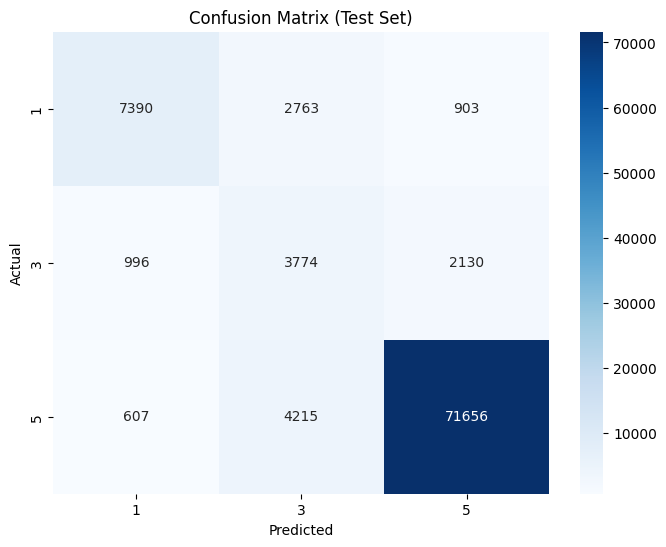

In [7]:
val_acc = accuracy_score(y_val, maxent_model.predict(X_val_vec))
print(f"Validation Accuracy: {val_acc:.4f}")

y_pred = maxent_model.predict(X_test_vec)
test_acc = accuracy_score(y_test, y_pred)

print(f"\n>>> FINAL TEST ACCURACY: {test_acc:.4f} ({test_acc*100:.2f}%) <<<\n")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=maxent_model.classes_, 
            yticklabels=maxent_model.classes_)
plt.title('Confusion Matrix (Test Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [8]:
def predict_new_comment(text):
    # Preprocess
    clean = clean_text(text)
    # Vectorize
    vec = vectorizer.transform([clean])
    # Predict
    pred_label = maxent_model.predict(vec)[0]
    pred_proba = np.max(maxent_model.predict_proba(vec))
    
    return pred_label, pred_proba

my_comments = [
    "The food was delicious!",
    
    "It is just normal, nothing special."
]

print("--- DEMO PREDICTION ---")
for comment in my_comments:
    label, confidence = predict_new_comment(comment)
    print(f"Comment: '{comment}'")
    print(f"-> Sentiment: {label} (Confidence: {confidence:.2%})\n")

--- DEMO PREDICTION ---


NameError: name 'clean_text' is not defined

In [10]:
import pickle

filename = 'me_model.sav'
pickle.dump(maxent_model, open(filename, 'wb'))

filename = 'me_vectorizer.sav'
pickle.dump(vectorizer, open(filename, 'wb'))